In [10]:
from Tools.analysis_tools import *

### Analysis Notebook for $ y_2(t) $ Reconstruction Performance:

This notebook evaluates the reconstruction performance of various network configurations, focusing on model comparisons. Key aspects analyzed include the impact of noise introduced by the $ \alpha $ and $ \beta $ parameters and the role of dimensionality reduction on performance.

In [11]:
# Percorso della cartella contenente i file CSV degli encoder
decoder_folder = "Decoder Analysis Data"

# Carica i dati
decoder_data = load_decoder_analysis_data(decoder_folder)

# Order the dataset
config_file = 'decoderDatabase.json'
enriched_data = enrich_analysis_with_config(decoder_data, config_file)

# Visualizza i dati ordinati
print(decoder_data.head())


Caricando dati da: Decoder Analysis Data/30-20,15.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0-2.csv
Caricando dati da: Decoder Analysis Data/30-20,3-1.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise10,15.csv
Caricando dati da: Decoder Analysis Data/30-20,3-2.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise0,10.csv
Caricando dati da: Decoder Analysis Data/30-20,3.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise10,10.csv
Caricando dati da: Decoder Analysis Data/30-20.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0-Deeper.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise0,15.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise5,5.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise15,0.csv
Caricando dati da: Decoder Analysis Data/30,20-Noise10,5.csv
Caricando dati da: Decoder Analysis Data/30-20_Noise10,0.csv
Caricando dati da: Decoder Analysis Data/30-20,5.csv
Caricando dati da: Decoder Analysis Data/30-20,10.csv
Caric

In [12]:
# Lista dei filtri

'''
filter_type: equals o range
filter_value: valore del parametro (numero o range)
'''

filters = [
    {"param_name": "tau", "filter_type": "equals", "filter_value": 15},
   # {"param_name": "beta", "filter_type": "equals", "filter_value": 0}
]

sorted_data = filter_by_config_params(enriched_data, filters,True) # True per visualizzare i dati filtrati, false per disattivare
filtered_data = sort_by_alpha_and_beta(sorted_data,"alpha", "beta")

### Reconstruction Metrics for the projected Hankel Matrices:

In this section, we present various metrics calculated directly from the network's output on the validation dataset.

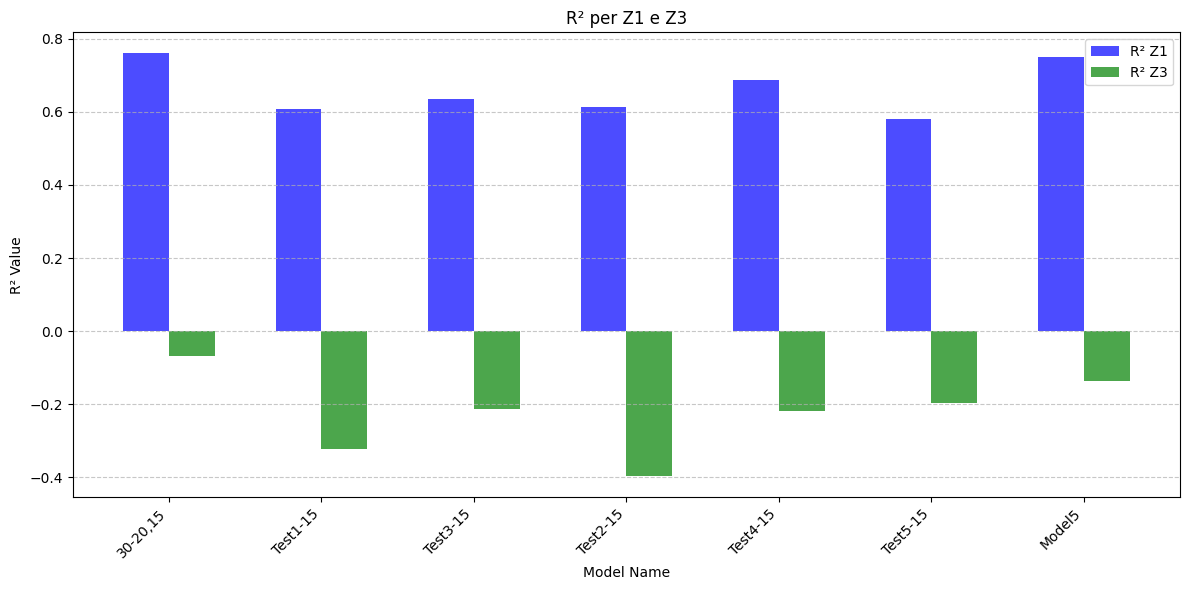

In [13]:
plot_r2_z1_z3(
    data=filtered_data,
    r2_z1_col="Z1 R2 Mean",  
    r2_z3_col="Z3 R2 Mean", 
    title="R² per Z1 e Z3"
)


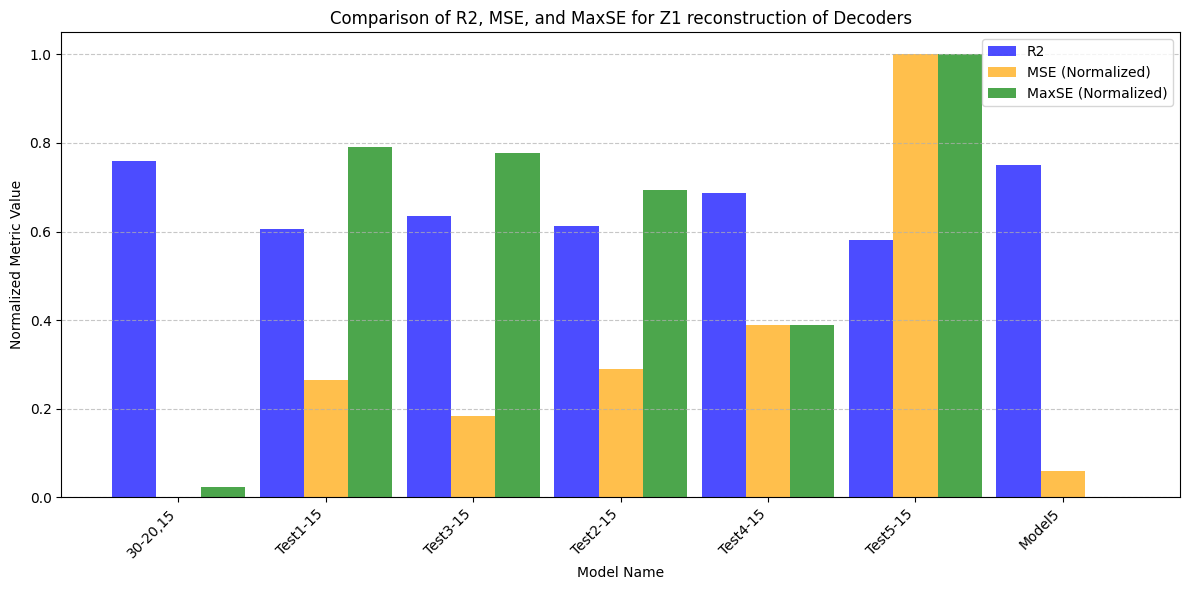

In [14]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z1 R2 Mean", 
    mse_col="Z1 MSE Mean", 
    maxse_col="Z1 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z1 reconstruction of Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!
# Disattivata normalizzazione di R^2


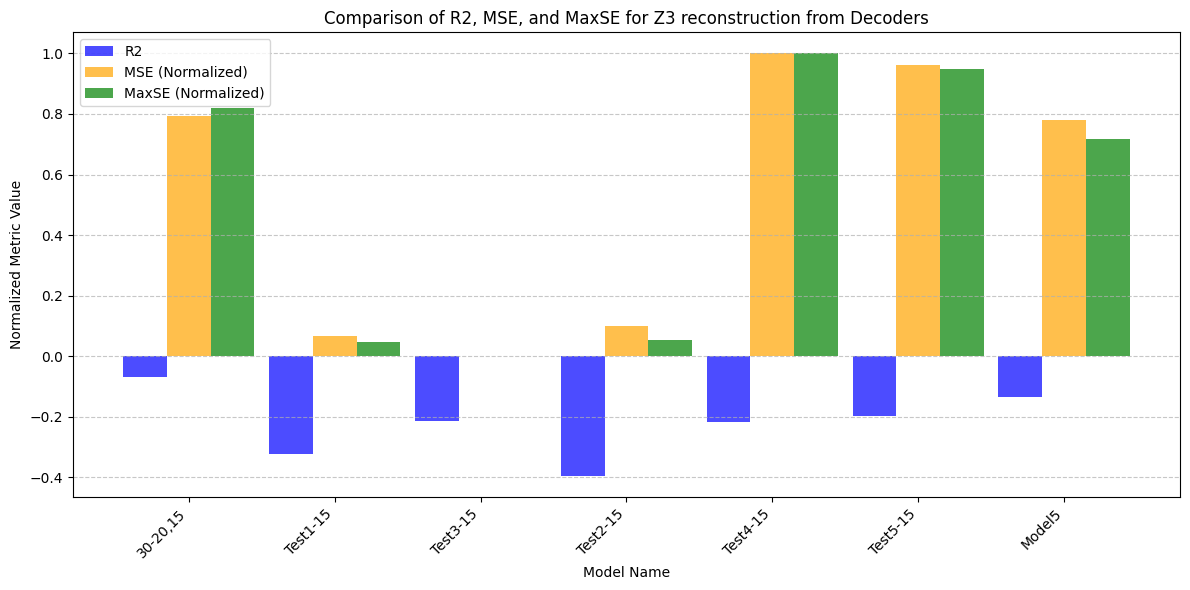

In [15]:
plot_z_metrics(
    data=filtered_data, 
    r2_col="Z3 R2 Mean", 
    mse_col="Z3 MSE Mean", 
    maxse_col="Z3 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z3 reconstruction from Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!


In the following graph, the $R^2$ is calculated using post-processed data. The time series is reconstructed by reversing the projection and unfolding the embedding.

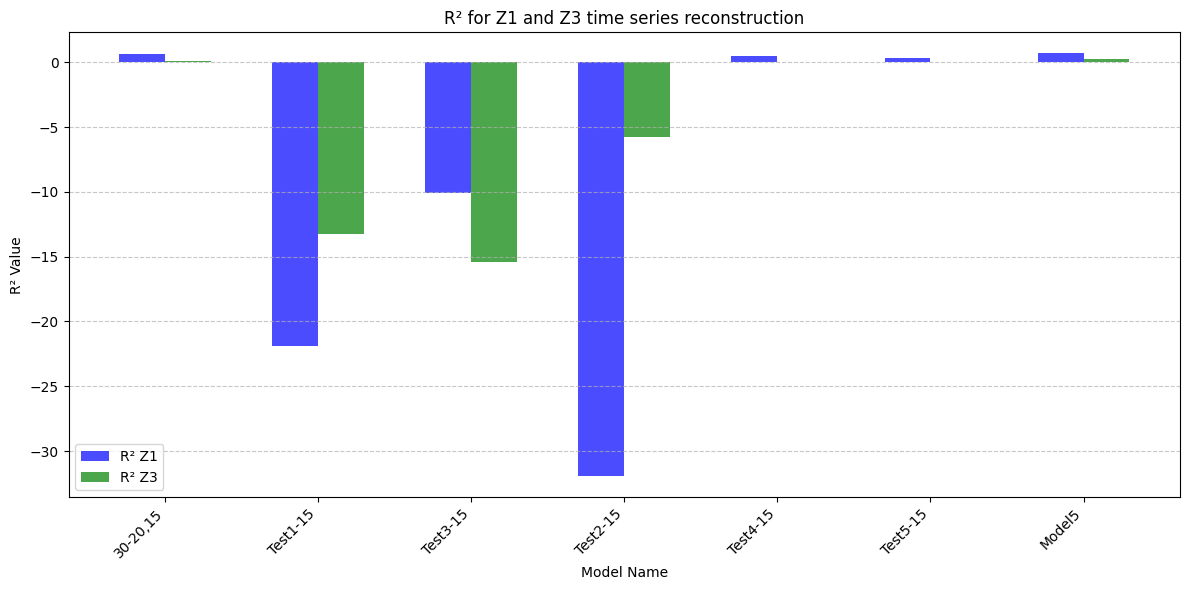

In [16]:
plot_r2_z1_z3(
    data=filtered_data,
    r2_z1_col="PCA R2 Time Signal Z1",  # Sostituisci con il nome della colonna corrispondente
    r2_z3_col="PCA R2 Time Signal Z3",  # Sostituisci con il nome della colonna corrispondente
    title="R² for Z1 and Z3 time series reconstruction"
)

#### PC's reconstruction Analysis:
This graph illustrates the reconstructed principal components (PCs) of the output data from the validation dataset.

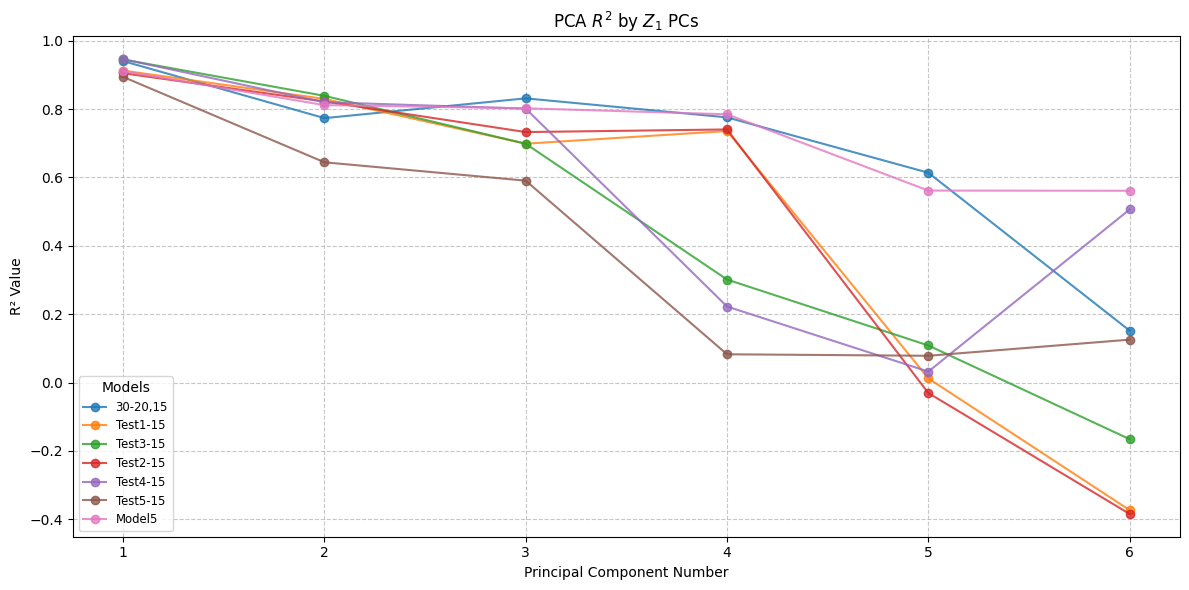

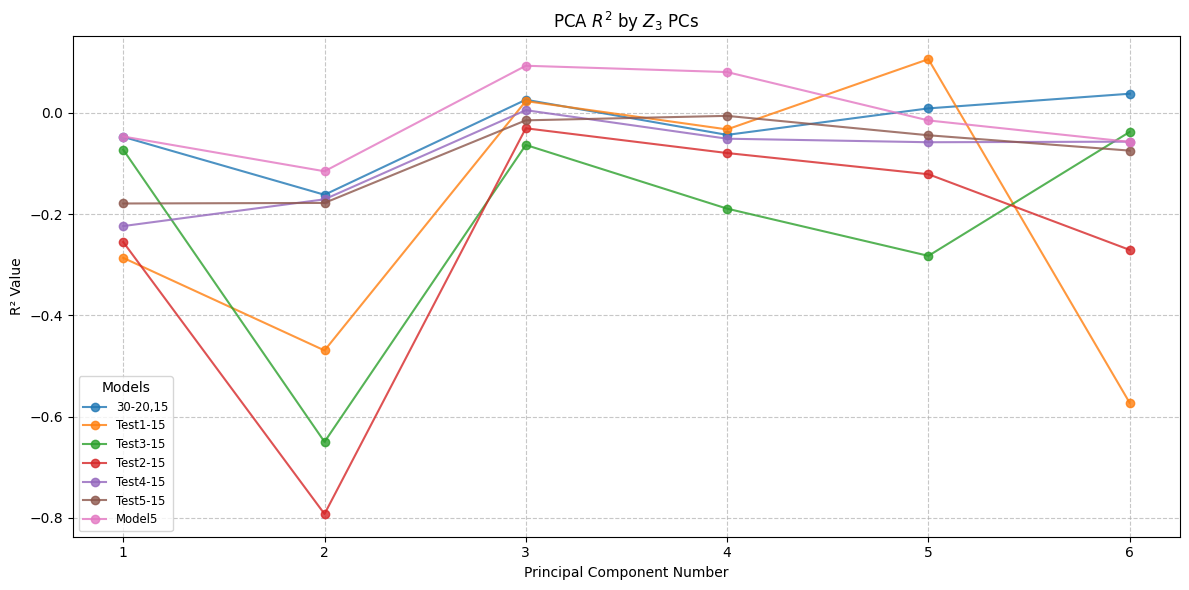

In [17]:
plot_r2_pca(
    data=filtered_data,
    r2_col="PCA R2 Z1 PC",
    variance_col="Varianzce Explained Z1",
    title= f"PCA $R^2$ by $Z_1$ PCs"
)
plot_r2_pca(
    data=filtered_data,
    r2_col="PCA R2 Z3 PC",
    variance_col="Varianzce Explained Z3",
    title= f"PCA $R^2$ by $Z_3$ PCs"
)

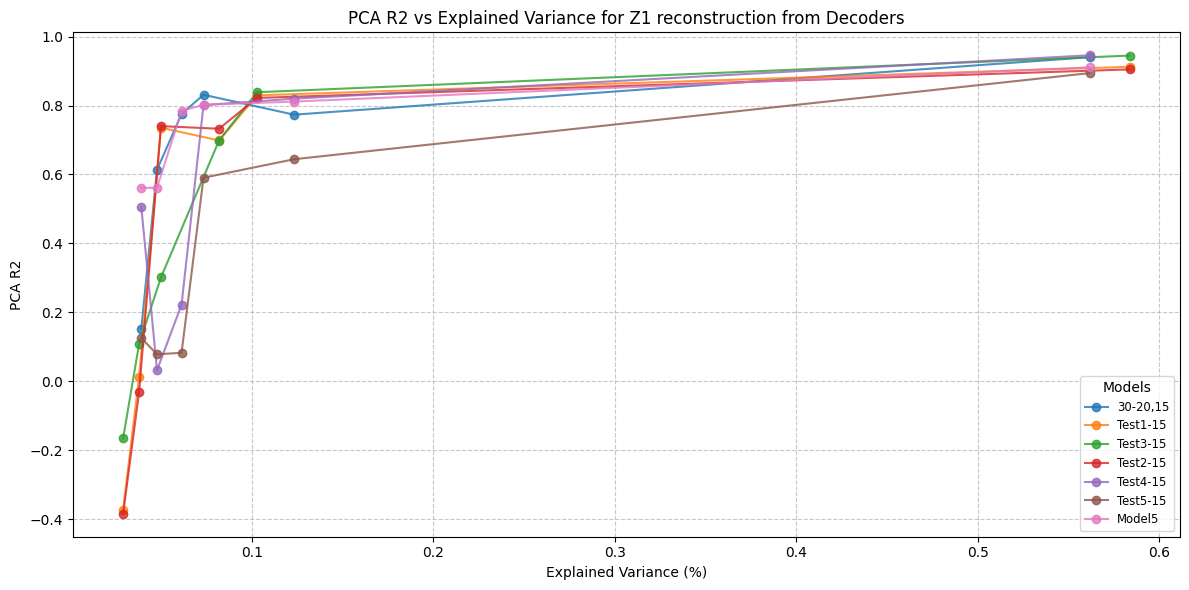

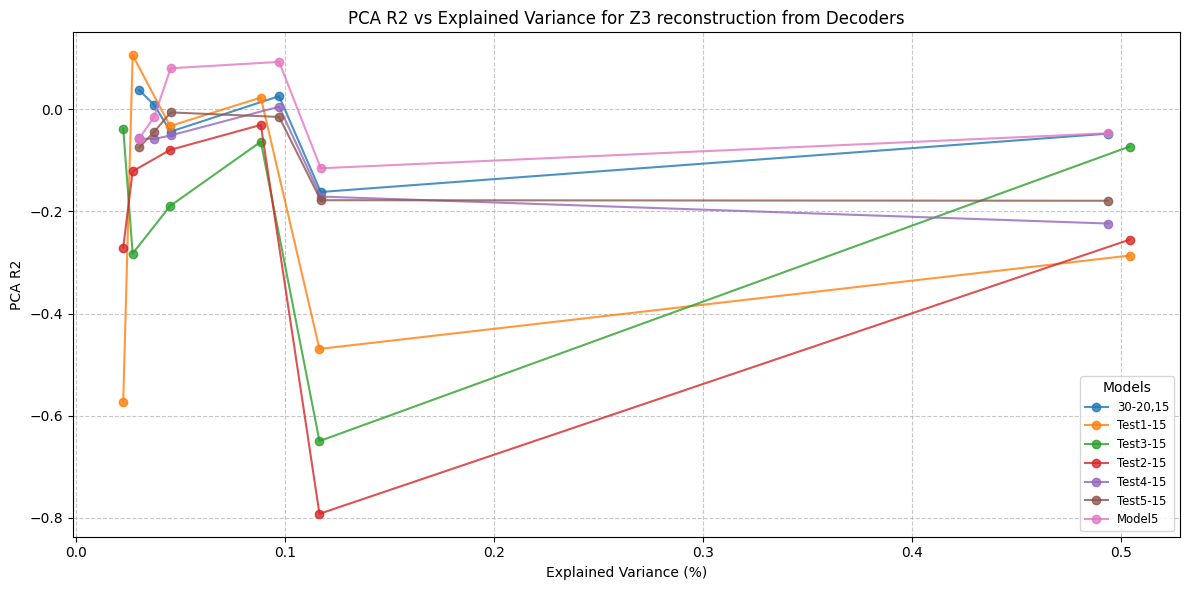

In [18]:
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z1 PC",
    variance_col="Varianzce Explained Z1",
    title="PCA R2 vs Explained Variance for Z1 reconstruction from Decoders"
)
plot_pca_r2_and_variance(
    data=filtered_data,
    r2_col="PCA R2 Z3 PC",
    variance_col="Varianzce Explained Z3",
    title="PCA R2 vs Explained Variance for Z3 reconstruction from Decoders"
)